# Midterm 1 Grade Analysis

**Problem structure:**
- A-1: 5 pts, A-2: 5 pts, A-3: 5 pts, A-4: 5 pts
- B-1: 40 pts, B-2: 20 pts
- **Total: 80 pts**


**Three Scenarios:**
1. Raw score (out of 80)
2. Raw score + base score 80  →  percentage = (raw + 80) / 160 × 100
3. Exclude B-2 from exam, add base score 60, use B-2 as bonus

**Grade Scale:**

| Grade | Threshold |
|-------|----------|
| A+    | > 97%    |
| A     | > 93%    |
| A-    | > 90%    |
| B+    | > 87%    |
| B     | > 83%    |
| B-    | > 80%    |
| C+    | > 77%    |
| C     | > 73%    |
| C-    | > 70%    |
| D+    | > 67%    |
| D     | > 63%    |
| D-    | > 60%    |
| F     | ≤ 60%   |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Load data ──────────────────────────────────────────────────────────────
df_raw = pd.read_excel('/Users/hoon/Downloads/Midterm1-score.xlsx', sheet_name='Total')

df_raw = df_raw.rename(columns={
    'Score':              'raw',
    '2: A-1 (5.0 pts)':  'A1',
    '3: A-2 (5.0 pts)':  'A2',
    '4: A-3 (5.0 pts)':  'A3',
    '5: A-4 (5.0 pts)':  'A4',
    '6: B-1 (40.0 pts)': 'B1',
    '7: B-2 (20.0 pts)': 'B2',
})

# Keep only score columns; use entry number as index (no names)
# Exclude entries with a total raw score of 0 (absent / no submission)
data = df_raw[['raw','A1','A2','A3','A4','B1','B2']].copy()
# data = data[data['raw'] > 0]
data.index = pd.RangeIndex(1, len(data)+1)
data.index.name = 'Entry'

MAX_SCORE = 80

print(f'Students: {len(data)}')
print('\nRaw score summary (out of 80):')
data['raw'].describe().round(2)

Students: 33

Raw score summary (out of 80):


count    33.00
mean     46.56
std      23.48
min       0.00
25%      31.00
50%      48.00
75%      65.00
max      80.00
Name: raw, dtype: float64

In [2]:
data

,raw,A1,A2,A3,A4,B1,B2
Entry,,,,,,,
1,80.0,5,5,5,5,40.0,20
2,80.0,5,5,5,5,40.0,20
3,47.0,5,5,5,0,29.0,3
4,31.0,4,3,0,0,8.0,16
5,37.0,4,4,0,0,26.0,3
6,60.0,5,5,5,5,40.0,0
7,0.0,0,0,0,0,0.0,0
8,51.0,5,5,0,0,32.0,9
9,67.0,5,5,1,5,33.0,18


In [5]:
scores = np.array(data['raw'])

print(f'Number of students: {len(scores)}')
print(f'Mean score: {scores.mean():.2f}')
print(f'Median score: {np.median(scores):.2f}')
print(f'Standard deviation: {scores.std(ddof=1):.2f}')  

# print(f"Minimum score: {scores.min()}")
# print(f"Maximum score: {scores.max()}")
# print(f"25th percentile: {np.percentile(scores, 25):.2f}")
# print(f"75th percentile: {np.percentile(scores, 75):.2f}")  
# print(f"Number of students scoring above 70: {(scores > 70).sum()}")

Number of students: 33
Mean score: 46.56
Median score: 48.00
Standard deviation: 23.48


## Raw Score Distribution

(array([2., 0., 1., 3., 2., 0., 2., 1., 3., 3., 3., 2., 2., 2., 2., 5.]),
 array([ 0.,  5., 10., 15., 20., 25., 30., 35., 40., 45., 50., 55., 60.,
        65., 70., 75., 80.]),
 <BarContainer object of 16 artists>)

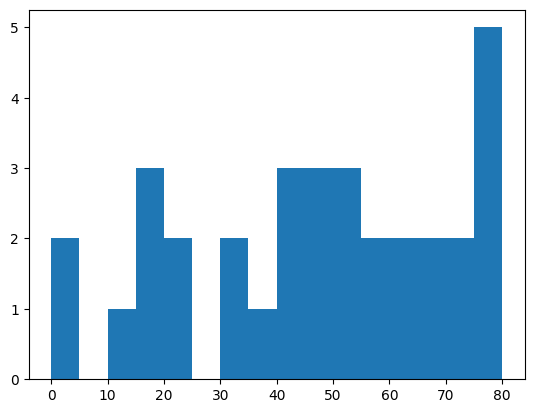

In [7]:
plt.hist(scores, bins=range(0, 85, 5))

ValueError: List of violinplot statistics and `positions` values must have the same length

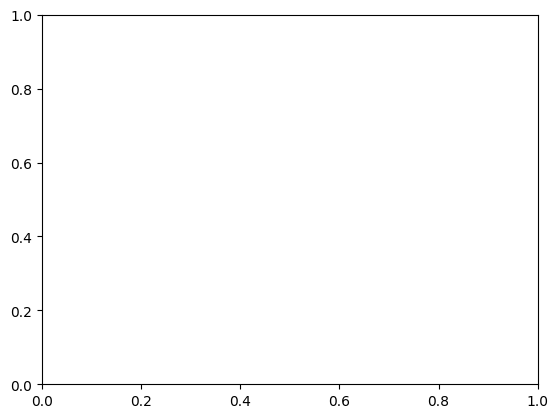

In [21]:
#pct_data = [data[col] / mx * 100 for col, mx in zip(problem_cols, problem_max)]

plt.violinplot(scores, positions=range(len(pct_data)))

In [17]:
pct_data

[Entry
 1     100.0
 2     100.0
 3     100.0
 4      80.0
 5      80.0
 6     100.0
 7       0.0
 8     100.0
 9     100.0
 10    100.0
 11    100.0
 12     80.0
 13     80.0
 14    100.0
 15    100.0
 16    100.0
 17    100.0
 18      0.0
 19     80.0
 20     80.0
 21    100.0
 22     80.0
 23     80.0
 24     80.0
 25      0.0
 26    100.0
 27    100.0
 28     80.0
 29    100.0
 30     80.0
 31     80.0
 32    100.0
 33    100.0
 Name: A1, dtype: float64,
 Entry
 1     100.0
 2     100.0
 3     100.0
 4      60.0
 5      80.0
 6     100.0
 7       0.0
 8     100.0
 9     100.0
 10    100.0
 11    100.0
 12     80.0
 13     40.0
 14    100.0
 15    100.0
 16    100.0
 17    100.0
 18    100.0
 19     80.0
 20      0.0
 21    100.0
 22     80.0
 23     80.0
 24     80.0
 25      0.0
 26    100.0
 27    100.0
 28     80.0
 29    100.0
 30     80.0
 31     80.0
 32    100.0
 33    100.0
 Name: A2, dtype: float64,
 Entry
 1     100.0
 2     100.0
 3     100.0
 4       0.0
 5       0.0
 6

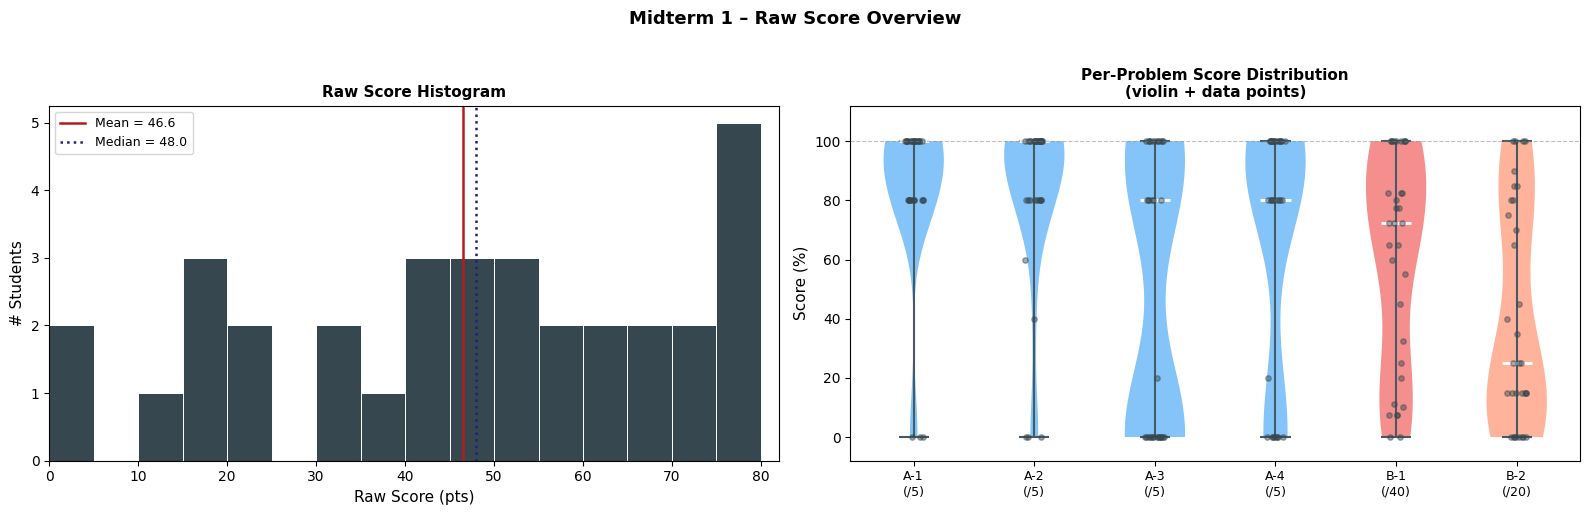

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: histogram ───────────────────────────────────────────────────────
ax = axes[0]
bins = range(0, 85, 5)
ax.hist(data['raw'], bins=bins, color='#37474F', edgecolor='white', linewidth=0.7)
mean_v   = data['raw'].mean()
median_v = data['raw'].median()
ax.axvline(mean_v,   color='#B71C1C', linewidth=1.8, label=f'Mean = {mean_v:.1f}')
ax.axvline(median_v, color='#1A237E', linewidth=1.8, linestyle=':', label=f'Median = {median_v:.1f}')
ax.set_xlabel('Raw Score (pts)', fontsize=11)
ax.set_ylabel('# Students', fontsize=11)
ax.set_xlim(0, 82)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_title('Raw Score Histogram', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)


# ── Right: per-problem violin ──────────────────────────────────────────────
ax = axes[1]
problem_cols   = ['A1', 'A2', 'A3', 'A4', 'B1', 'B2']
problem_max    = [5,    5,    5,    5,    40,   20  ]
problem_labels = ['A-1\n(/5)', 'A-2\n(/5)', 'A-3\n(/5)', 'A-4\n(/5)', 'B-1\n(/40)', 'B-2\n(/20)']
pct_data = [data[col] / mx * 100 for col, mx in zip(problem_cols, problem_max)]
colors   = ['#42A5F5','#42A5F5','#42A5F5','#42A5F5','#EF5350','#FF8A65']

vp = ax.violinplot(pct_data, positions=range(len(pct_data)), showmedians=True, showextrema=True)
for body, color in zip(vp['bodies'], colors):
    body.set_facecolor(color)
    body.set_alpha(0.65)
vp['cmedians'].set_color('white')
vp['cmedians'].set_linewidth(2)
for part in ['cmins','cmaxes','cbars']:
    vp[part].set_color('#455A64')

# Overlay jittered data points
rng = np.random.default_rng(1)
for i, col_data in enumerate(pct_data):
    jitter = rng.uniform(-0.08, 0.08, size=len(col_data))
    ax.scatter(i + jitter, col_data, color='#37474F', alpha=0.45, s=15, zorder=2)

ax.set_xticks(range(len(problem_cols)))
ax.set_xticklabels(problem_labels, fontsize=9)
ax.set_ylabel('Score (%)', fontsize=11)
ax.set_ylim(-8, 112)
ax.axhline(100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Per-Problem Score Distribution\n(violin + data points)', fontsize=11, fontweight='bold')

plt.suptitle('Midterm 1 – Raw Score Overview', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [4]:
# ── Grade helper ───────────────────────────────────────────────────────────
def assign_grade(pct):
    if   pct > 97: return 'A+'
    elif pct > 93: return 'A'
    elif pct > 90: return 'A-'
    elif pct > 87: return 'B+'
    elif pct > 83: return 'B'
    elif pct > 80: return 'B-'
    elif pct > 77: return 'C+'
    elif pct > 73: return 'C'
    elif pct > 70: return 'C-'
    elif pct > 67: return 'D+'
    elif pct > 63: return 'D'
    elif pct > 60: return 'D-'
    else:          return 'F'

GRADE_ORDER = ['A+','A','A-','B+','B','B-','C+','C','C-','D+','D','D-','F']

## Scenario 1 – Raw Score

In [5]:
data['S1_pct']   = data['raw'] / MAX_SCORE * 100
data['S1_grade'] = data['S1_pct'].apply(assign_grade)

print('Scenario 1 – Raw Score')
print(f"  Mean:   {data['S1_pct'].mean():.1f}%")
print(f"  Median: {data['S1_pct'].median():.1f}%")
print(f"  Std:    {data['S1_pct'].std():.1f}%")
s1_dist = data['S1_grade'].value_counts().reindex(GRADE_ORDER, fill_value=0)
print('\nGrade distribution:')
print(s1_dist[s1_dist > 0].to_string())

Scenario 1 – Raw Score
  Mean:   58.2%
  Median: 60.0%
  Std:    29.3%

Grade distribution:
S1_grade
A+     3
A      2
B+     2
B      1
B-     1
C      2
C-     2
D      3
F     17


## Scenario 2 – Raw Score + Base Score 80

In [6]:
BASE_S2 = 80

data['S2_pct']   = (data['raw'] + BASE_S2) / (MAX_SCORE + BASE_S2) * 100
data['S2_grade'] = data['S2_pct'].apply(assign_grade)

print('Scenario 2 – Raw + Base')
print(f"  Mean:   {data['S2_pct'].mean():.1f}%")
print(f"  Median: {data['S2_pct'].median():.1f}%")
print(f"  Std:    {data['S2_pct'].std():.1f}%")
s2_dist = data['S2_grade'].value_counts().reindex(GRADE_ORDER, fill_value=0)
print('\nGrade distribution:')
print(s2_dist[s2_dist > 0].to_string())

Scenario 2 – Raw + Base
  Mean:   79.1%
  Median: 80.0%
  Std:    14.7%

Grade distribution:
S2_grade
A+    5
A     2
A-    2
B+    2
B     3
B-    2
C+    5
C     2
D+    2
D     2
D-    1
F     5


## Scenario 3 – B-2 as Bonus

- Exam score (excl. B-2) out of 60
- B-2 (0–20 pts) added as bonus on top

In [7]:
BASE_S3   = 0
MAX_NO_B2 = MAX_SCORE - 20   # 60
DENOM_S3  = MAX_NO_B2 + BASE_S3  # 120

data['S3_exam']  = data['raw'] - data['B2']           # score excl. B-2
data['S3_total'] = data['S3_exam'] + BASE_S3 + data['B2']  # = raw + 60
data['S3_pct']   = data['S3_total'] / DENOM_S3 * 100
data['S3_grade'] = data['S3_pct'].apply(assign_grade)

print('Scenario 3 – B-2 Bonus')
print(f"  Mean:   {data['S3_pct'].mean():.1f}%")
print(f"  Median: {data['S3_pct'].median():.1f}%")
print(f"  Std:    {data['S3_pct'].std():.1f}%")
s3_dist = data['S3_grade'].value_counts().reindex(GRADE_ORDER, fill_value=0)
print('\nGrade distribution:')
print(s3_dist[s3_dist > 0].to_string())

Scenario 3 – B-2 Bonus
  Mean:   77.6%
  Median: 80.0%
  Std:    39.1%

Grade distribution:
S3_grade
A+    11
A      2
B+     1
B      2
C+     2
C      3
D      1
D-     1
F     10


## Scenario 4 – Square Root Curve

A standard non-linear curve: `adjusted (%) = sqrt(raw / 80) × 100`

- Monotone: higher raw score always yields higher curved score
- Larger benefit for lower scores, diminishing benefit near the top
- Published, named technique widely accepted in academia

In [8]:
data['S4_pct']   = np.sqrt(data['raw'] / MAX_SCORE) * 100
data['S4_grade'] = data['S4_pct'].apply(assign_grade)

print('Scenario 4 – Square Root Curve')
print(f"  Mean:   {data['S4_pct'].mean():.1f}%")
print(f"  Median: {data['S4_pct'].median():.1f}%")
print(f"  Std:    {data['S4_pct'].std():.1f}%")
s4_dist = data['S4_grade'].value_counts().reindex(GRADE_ORDER, fill_value=0)
print('\nGrade distribution:')
print(s4_dist[s4_dist > 0].to_string())


Scenario 4 – Square Root Curve
  Mean:   72.1%
  Median: 77.5%
  Std:    25.5%

Grade distribution:
S4_grade
A+    5
A     2
A-    2
B+    1
B     3
B-    2
C+    2
C     4
C-    1
D+    1
D     1
D-    1
F     8


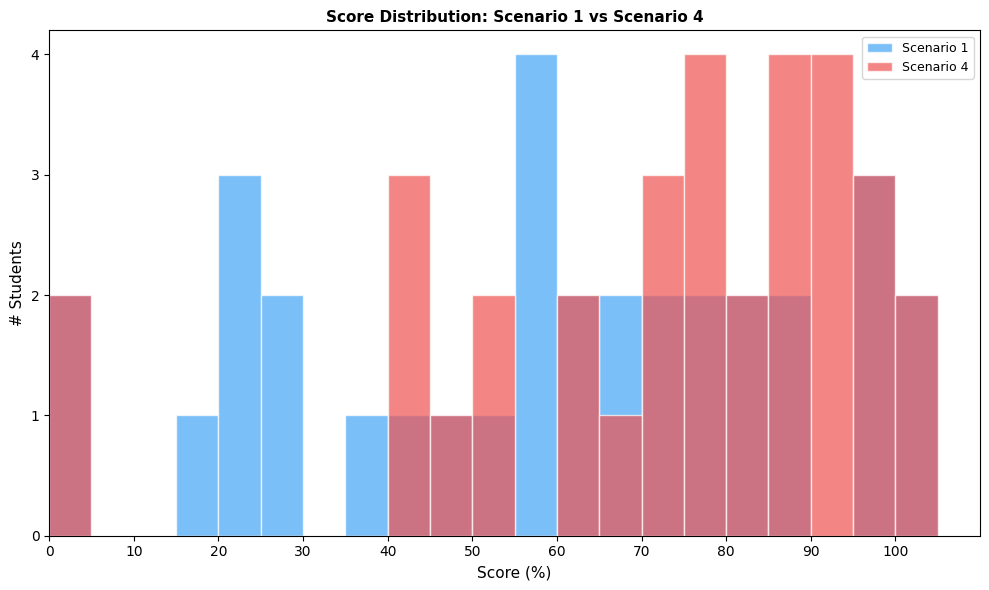

In [9]:
# compare distribution of S1 and S4

plt.figure(figsize=(10, 6))
plt.hist(data['S1_pct'], bins=range(0, 110, 5), alpha=0.7, label='Scenario 1', color='#42A5F5', edgecolor='white')
plt.hist(data['S4_pct'], bins=range(0, 110, 5), alpha=0.7, label='Scenario 4', color='#EF5350', edgecolor='white')
plt.xlabel('Score (%)', fontsize=11)
plt.ylabel('# Students', fontsize=11)
plt.title('Score Distribution: Scenario 1 vs Scenario 4', fontsize=11, fontweight='bold')
plt.xlim(0, 110)
plt.xticks(range(0, 110, 10))
plt.gca().yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Summary Table (all entries)

In [10]:
summary = pd.DataFrame({
    'S1_pct (%)':  data['S1_pct'].round(1),
    'S1_grade':    data['S1_grade'],
    'S2_pct (%)':  data['S2_pct'].round(1),
    'S2_grade':    data['S2_grade'],
    'S3_pct (%)':  data['S3_pct'].round(1),
    'S3_grade':    data['S3_grade'],
    'S4_pct (%)':  data['S4_pct'].round(1),
    'S4_grade':    data['S4_grade'],
})
print(summary.to_string())


       S1_pct (%) S1_grade  S2_pct (%) S2_grade  S3_pct (%) S3_grade  S4_pct (%) S4_grade
Entry                                                                                    
1           100.0       A+       100.0       A+       133.3       A+       100.0       A+
2           100.0       A+       100.0       A+       133.3       A+       100.0       A+
3            58.8        F        79.4       C+        78.3       C+        76.6        C
4            38.8        F        69.4       D+        51.7        F        62.2       D-
5            46.2        F        73.1        C        61.7       D-        68.0       D+
6            75.0        C        87.5       B+       100.0       A+        86.6        B
7             0.0        F        50.0        F         0.0        F         0.0        F
8            63.7        D        81.9       B-        85.0        B        79.8       C+
9            83.8        B        91.9       A-       111.7       A+        91.5       A-
10        

## Grade Distribution Comparison

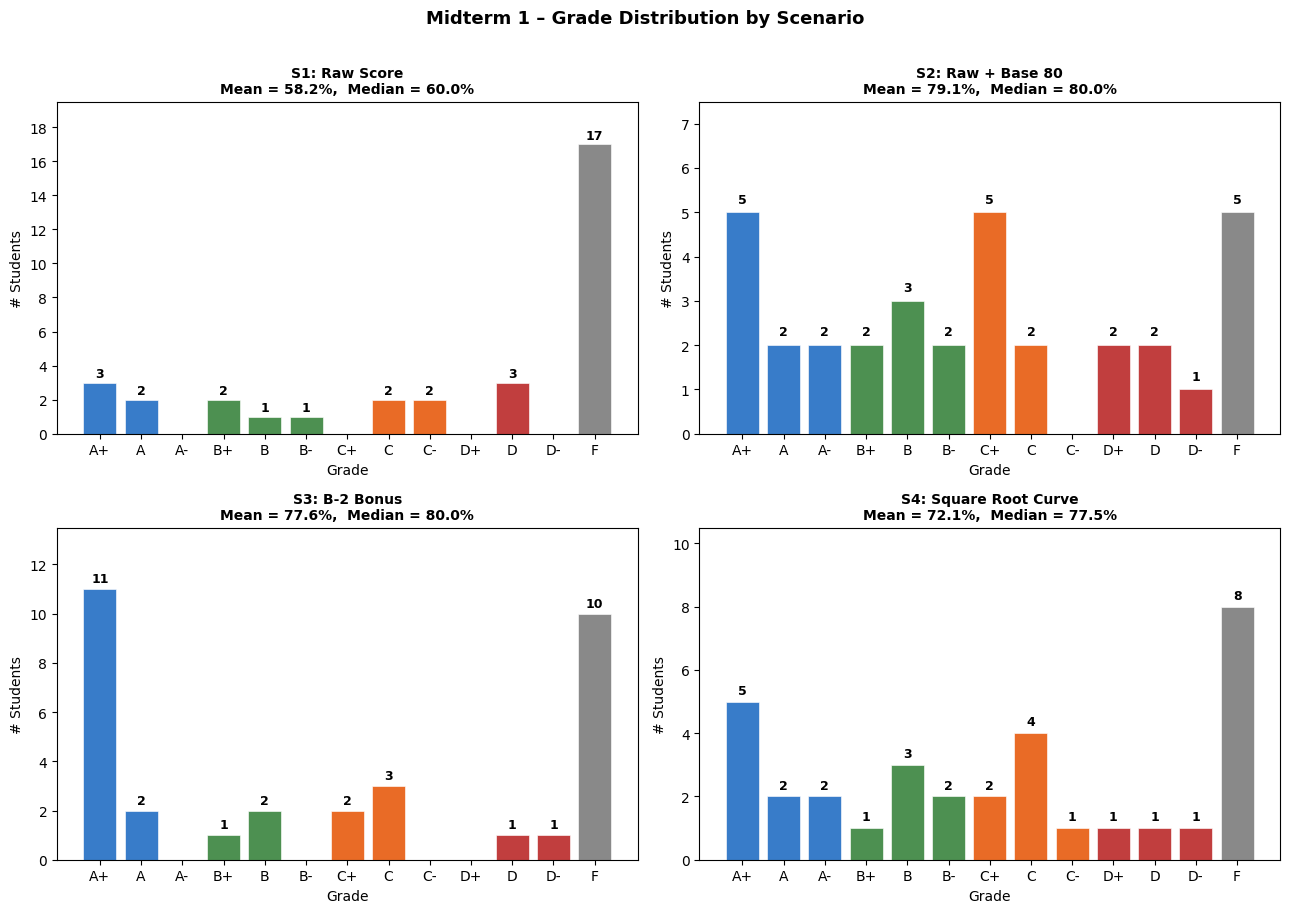

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

scenarios = [
    (data['S1_pct'], data['S1_grade'], 'S1: Raw Score'),
    (data['S2_pct'], data['S2_grade'], 'S2: Raw + Base 80'),
    (data['S3_pct'], data['S3_grade'], 'S3: B-2 Bonus'),
    (data['S4_pct'], data['S4_grade'], 'S4: Square Root Curve'),
]

GRADE_COLORS = {
    'A': '#1565C0', 'B': '#2E7D32', 'C': '#E65100', 'D': '#B71C1C', 'F': '#757575'
}

for ax, (pcts, grades, title) in zip(axes, scenarios):
    dist = grades.value_counts().reindex(GRADE_ORDER, fill_value=0)
    colors = [GRADE_COLORS.get(g[0], '#757575') for g in GRADE_ORDER]
    bars = ax.bar(GRADE_ORDER, dist.values, color=colors, edgecolor='white', linewidth=0.5, alpha=0.85)
    for bar, val in zip(bars, dist.values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                    str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xlabel('Grade')
    ax.set_ylabel('# Students')
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.set_ylim(0, max(dist.values) + 2.5)
    ax.set_title(f'{title}\nMean = {pcts.mean():.1f}%,  Median = {pcts.median():.1f}%',
                 fontsize=10, fontweight='bold')

plt.suptitle('Midterm 1 – Grade Distribution by Scenario', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


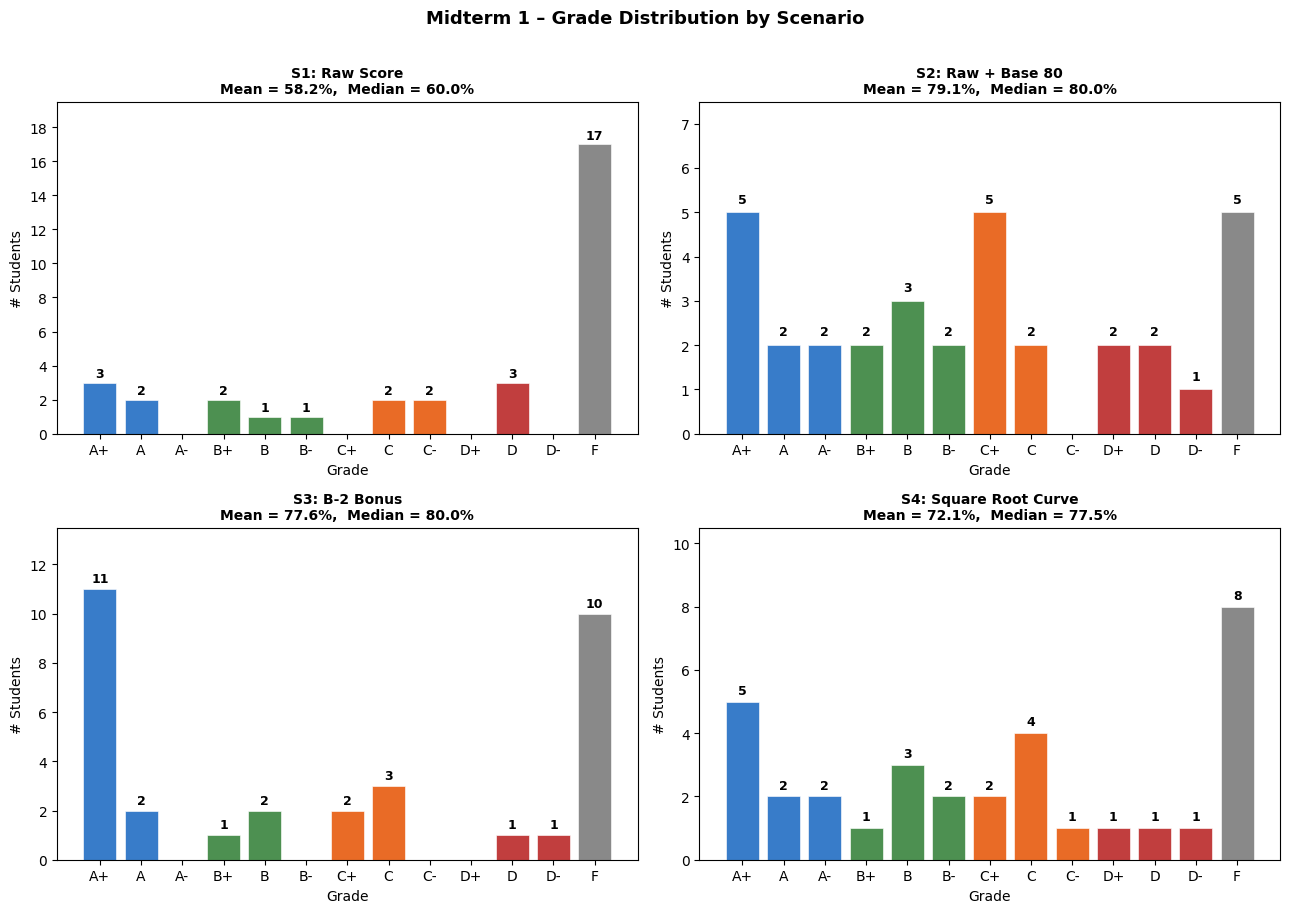

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

scenarios = [
    (data['S1_pct'], data['S1_grade'], 'S1: Raw Score'),
    (data['S2_pct'], data['S2_grade'], 'S2: Raw + Base 80'),
    (data['S3_pct'], data['S3_grade'], 'S3: B-2 Bonus'),
    (data['S4_pct'], data['S4_grade'], 'S4: Square Root Curve'),
]

GRADE_COLORS = {
    'A': '#1565C0', 'B': '#2E7D32', 'C': '#E65100', 'D': '#B71C1C', 'F': '#757575'
}

for ax, (pcts, grades, title) in zip(axes, scenarios):
    dist = grades.value_counts().reindex(GRADE_ORDER, fill_value=0)
    colors = [GRADE_COLORS.get(g[0], '#757575') for g in GRADE_ORDER]
    bars = ax.bar(GRADE_ORDER, dist.values, color=colors, edgecolor='white', linewidth=0.5, alpha=0.85)
    for bar, val in zip(bars, dist.values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                    str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xlabel('Grade')
    ax.set_ylabel('# Students')
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.set_ylim(0, max(dist.values) + 2.5)
    ax.set_title(f'{title}\nMean = {pcts.mean():.1f}%,  Median = {pcts.median():.1f}%',
                 fontsize=10, fontweight='bold')

plt.suptitle('Midterm 1 – Grade Distribution by Scenario', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## Score Histograms (per scenario)

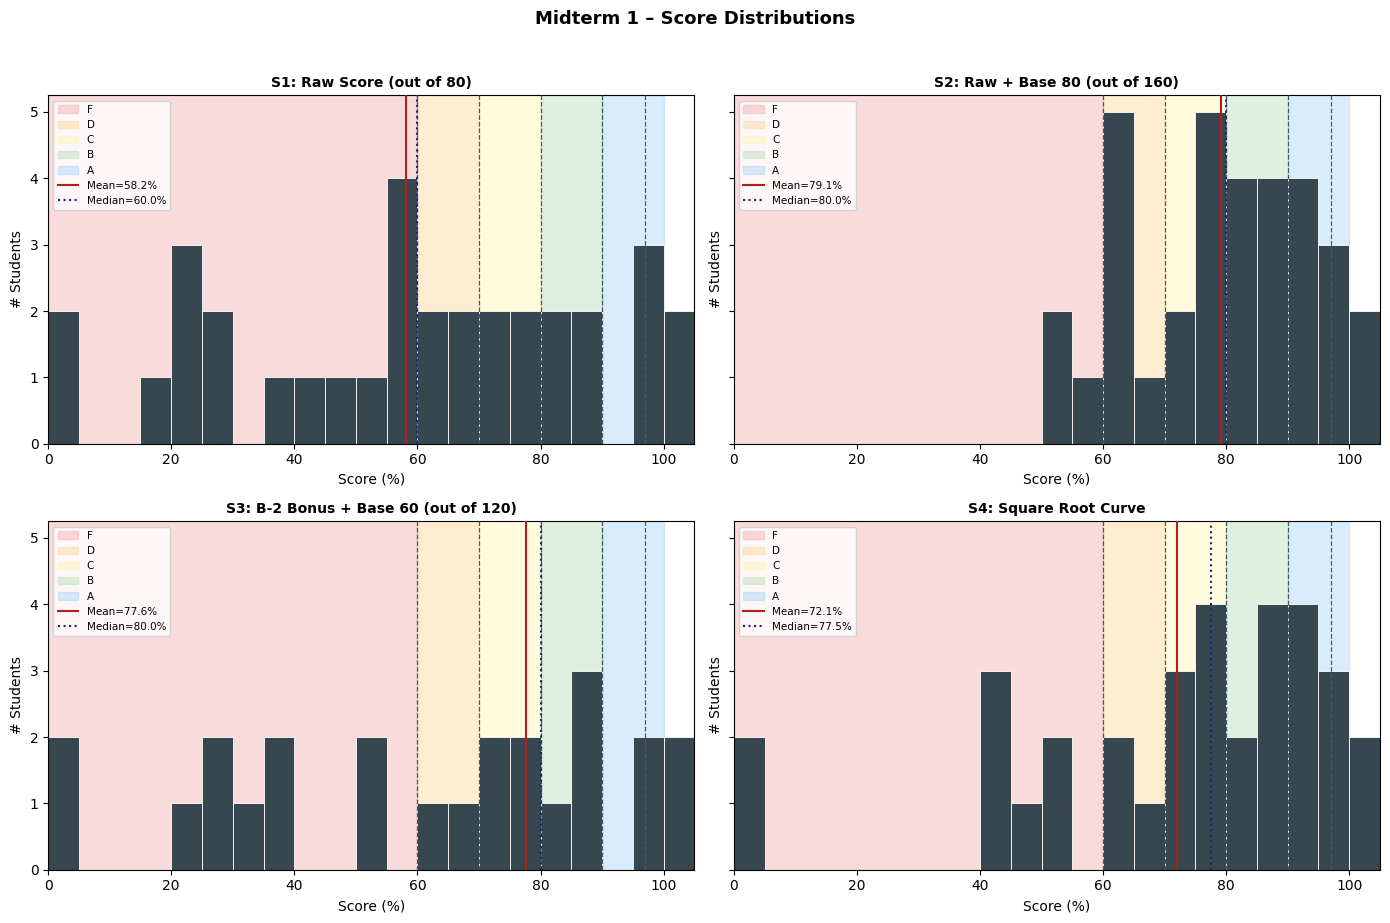

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
axes = axes.flatten()

scenarios = [
    (data['S1_pct'], 'S1: Raw Score (out of 80)'),
    (data['S2_pct'], 'S2: Raw + Base 80 (out of 160)'),
    (data['S3_pct'], 'S3: B-2 Bonus + Base 60 (out of 120)'),
    (data['S4_pct'], 'S4: Square Root Curve'),
]

grade_zones = [
    (0,  60,  '#EF9A9A', 'F'),
    (60, 70,  '#FFCC80', 'D'),
    (70, 80,  '#FFF59D', 'C'),
    (80, 90,  '#A5D6A7', 'B'),
    (90, 100, '#90CAF9', 'A'),
]

bins = range(0, 106, 5)

for ax, (pcts, title) in zip(axes, scenarios):
    for lo, hi, color, label in grade_zones:
        ax.axvspan(lo, hi, color=color, alpha=0.35, label=label)
    ax.hist(pcts, bins=bins, color='#37474F', edgecolor='white', linewidth=0.6, zorder=2)
    for pct in [60, 70, 80, 90, 97]:
        ax.axvline(pct, color='#455A64', linestyle='--', linewidth=0.9, zorder=3)
    mean_v   = pcts.mean()
    median_v = pcts.median()
    ax.axvline(mean_v,   color='#B71C1C', linewidth=1.5, zorder=4, label=f'Mean={mean_v:.1f}%')
    ax.axvline(median_v, color='#1A237E', linewidth=1.5, linestyle=':', zorder=4, label=f'Median={median_v:.1f}%')
    ax.set_xlabel('Score (%)', fontsize=10)
    ax.set_ylabel('# Students', fontsize=10)
    ax.set_xlim(0, 105)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7.5, loc='upper left')

plt.suptitle('Midterm 1 – Score Distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Statistics & Grade Counts Summary

In [14]:
stats = pd.DataFrame({
    'Scenario': ['S1: Raw', 'S2: Base 80', 'S3: B-2 Bonus', 'S4: Sqrt Curve'],
    'Mean (%)':    [data['S1_pct'].mean(),   data['S2_pct'].mean(),   data['S3_pct'].mean(),   data['S4_pct'].mean()],
    'Median (%)':  [data['S1_pct'].median(), data['S2_pct'].median(), data['S3_pct'].median(), data['S4_pct'].median()],
    'Std (%)':     [data['S1_pct'].std(),    data['S2_pct'].std(),    data['S3_pct'].std(),    data['S4_pct'].std()],
    'Min (%)':     [data['S1_pct'].min(),    data['S2_pct'].min(),    data['S3_pct'].min(),    data['S4_pct'].min()],
    'Max (%)':     [data['S1_pct'].max(),    data['S2_pct'].max(),    data['S3_pct'].max(),    data['S4_pct'].max()],
    '# A/A+/A-':   [
        data['S1_grade'].isin(['A+','A','A-']).sum(),
        data['S2_grade'].isin(['A+','A','A-']).sum(),
        data['S3_grade'].isin(['A+','A','A-']).sum(),
        data['S4_grade'].isin(['A+','A','A-']).sum(),
    ],
    '# Pass (>60%)': [
        (data['S1_pct'] > 60).sum(),
        (data['S2_pct'] > 60).sum(),
        (data['S3_pct'] > 60).sum(),
        (data['S4_pct'] > 60).sum(),
    ],
    '# F': [
        (data['S1_grade'] == 'F').sum(),
        (data['S2_grade'] == 'F').sum(),
        (data['S3_grade'] == 'F').sum(),
        (data['S4_grade'] == 'F').sum(),
    ],
}).set_index('Scenario').round(1)

print(stats.to_string())

print('\n── Grade counts ──')
dist_table = pd.DataFrame({
    'S1: Raw':        data['S1_grade'].value_counts(),
    'S2: Base 80':    data['S2_grade'].value_counts(),
    'S3: B-2 Bonus':  data['S3_grade'].value_counts(),
    'S4: Sqrt Curve': data['S4_grade'].value_counts(),
}).reindex(GRADE_ORDER).fillna(0).astype(int)
dist_table.index.name = 'Grade'
print(dist_table.to_string())


                Mean (%)  Median (%)  Std (%)  Min (%)  Max (%)  # A/A+/A-  # Pass (>60%)  # F
Scenario                                                                                      
S1: Raw             58.2        60.0     29.3      0.0    100.0          5             16   17
S2: Base 80         79.1        80.0     14.7     50.0    100.0          9             28    5
S3: B-2 Bonus       77.6        80.0     39.1      0.0    133.3         13             23   10
S4: Sqrt Curve      72.1        77.5     25.5      0.0    100.0          9             25    8

── Grade counts ──
       S1: Raw  S2: Base 80  S3: B-2 Bonus  S4: Sqrt Curve
Grade                                                     
A+           3            5             11               5
A            2            2              2               2
A-           0            2              0               2
B+           2            2              1               1
B            1            3              2              